In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import joblib
from category_encoders import TargetEncoder
from sklearn.preprocessing import RobustScaler, StandardScaler
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from torch.optim import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import random
import os

from pathlib import Path
FIGURES_DIR = Path('../artifacts/nn/')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Установка всех сидов для полной воспроизводимости
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Для детерминистичности на GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
import mlflow
import mlflow.pytorch

mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Credit_Prediction_Experiments_NN")

z:\projects\AIE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
z:\projects\AIE\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:z:/projects/AIE/project/notebooks/mlruns/271779581847078824', creation_time=1778321673227, experiment_id='271779581847078824', last_update_time=1778321673227, lifecycle_stage='active', name='Credit_Prediction_Experiments_NN', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv('../data/CreditPrediction.csv')

In [4]:
df.head(10)

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Unnamed: 19
0,768805383,45.0,M,3,High School,Married,$60K - $80K,Blue,39.0,5.0,1,3,12691.0,777,1.335,1144,42,1.625,0.061,NaN
1,818770008,49.0,F,5,Graduate,NaN,Less than $40K,Blue,44.0,6.0,1,2,8256.0,864,1.541,1291,33,3.714,0.105,NaN
2,713982108,51.0,M,3,Graduate,Married,$80K - $120K,Blue,36.0,4.0,1,0,3418.0,0,2.594,1887,20,2.333,0.000,NaN
3,769911858,40.0,F,4,High School,NaN,Less than $40K,Blue,34.0,3.0,4,1,3313.0,2517,1.405,1171,20,2.333,0.760,NaN
4,709106358,40.0,M,3,Uneducated,Married,$60K - $80K,NaN,21.0,5.0,1,0,4716.0,0,2.175,816,28,2.500,0.000,NaN
5,713061558,44.0,M,2,Graduate,Married,$40K - $60K,Blue,36.0,3.0,1,2,4010.0,1247,1.376,1088,24,0.846,0.311,NaN
6,810347208,51.0,M,4,Unknown,Married,$120K +,Gold,46.0,6.0,1,3,34516.0,2264,1.975,1330,31,0.722,0.066,NaN
7,818906208,32.0,M,0,High School,Unknown,$60K - $80K,Silver,27.0,2.0,2,2,29081.0,1396,2.204,1538,36,0.714,0.048,NaN
8,710930508,37.0,M,3,Uneducated,Single,$60K - $80K,NaN,36.0,5.0,2,0,22352.0,2517,3.355,1350,24,1.182,0.113,NaN
9,719661558,48.0,M,2,Graduate,Single,$80K - $120K,Blue,36.0,6.0,3,3,11656.0,1677,1.524,1441,32,0.882,0.144,NaN


In [5]:
df = df.drop(columns=['CLIENTNUM', 'Unnamed: 19'])

In [6]:
df.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10167.000000,10167.000000,9944.000000,10147.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000
mean,46.753817,2.346513,35.913415,3.813245,2.341595,2.455887,8632.552346,1162.176748,0.759721,4402.349661,64.864463,0.712192,0.274716
std,13.520505,1.298701,7.980102,1.554741,1.010502,1.105580,9087.333842,815.082643,0.219054,3393.953441,23.461680,0.237934,0.275638
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2556.500000,348.500000,0.631000,2155.500000,45.000000,0.582000,0.022000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,0.736000,3900.000000,67.000000,0.702000,0.175000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1783.000000,0.859000,4740.000000,81.000000,0.818000,0.502500
max,352.330517,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10167 entries, 0 to 10166
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              10167 non-null  float64
 1   Gender                    9968 non-null   object 
 2   Dependent_count           10167 non-null  int64  
 3   Education_Level           10167 non-null  object 
 4   Marital_Status            8217 non-null   object 
 5   Income_Category           10167 non-null  object 
 6   Card_Category             8243 non-null   object 
 7   Months_on_book            9944 non-null   float64
 8   Total_Relationship_Count  10147 non-null  float64
 9   Months_Inactive_12_mon    10167 non-null  int64  
 10  Contacts_Count_12_mon     10167 non-null  int64  
 11  Credit_Limit              10167 non-null  float64
 12  Total_Revolving_Bal       10167 non-null  int64  
 13  Total_Amt_Chng_Q4_Q1      10167 non-null  float64
 14  Total_

In [8]:
df = df[(df['Customer_Age'] <= 80)] # (df['Total_Amt_Chng_Q4_Q1'] <= 2.8) & 
print(f'Размер данных после удаления аномалий: {df.shape[0]}')

Размер данных после удаления аномалий: 10150


In [9]:
target_col = "Credit_Limit"
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != target_col]
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [10]:
print(f'Уникальные значения для категориальных колонок:')

for col_name in cat_cols:
    print(f'{col_name} - {df[col_name].unique()}', end='\n\n')

Уникальные значения для категориальных колонок:
Gender - ['M' 'F' nan]

Education_Level - ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']

Marital_Status - ['Married' nan 'Unknown' 'Single' 'Divorced']

Income_Category - ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']

Card_Category - ['Blue' nan 'Gold' 'Silver' 'Platinum']



In [11]:
for col_name in cat_cols:
    df[col_name] = df[col_name].fillna('Unknown')

In [12]:
for col_name in num_cols:
    df[col_name] = df[col_name].fillna(df[col_name].median())

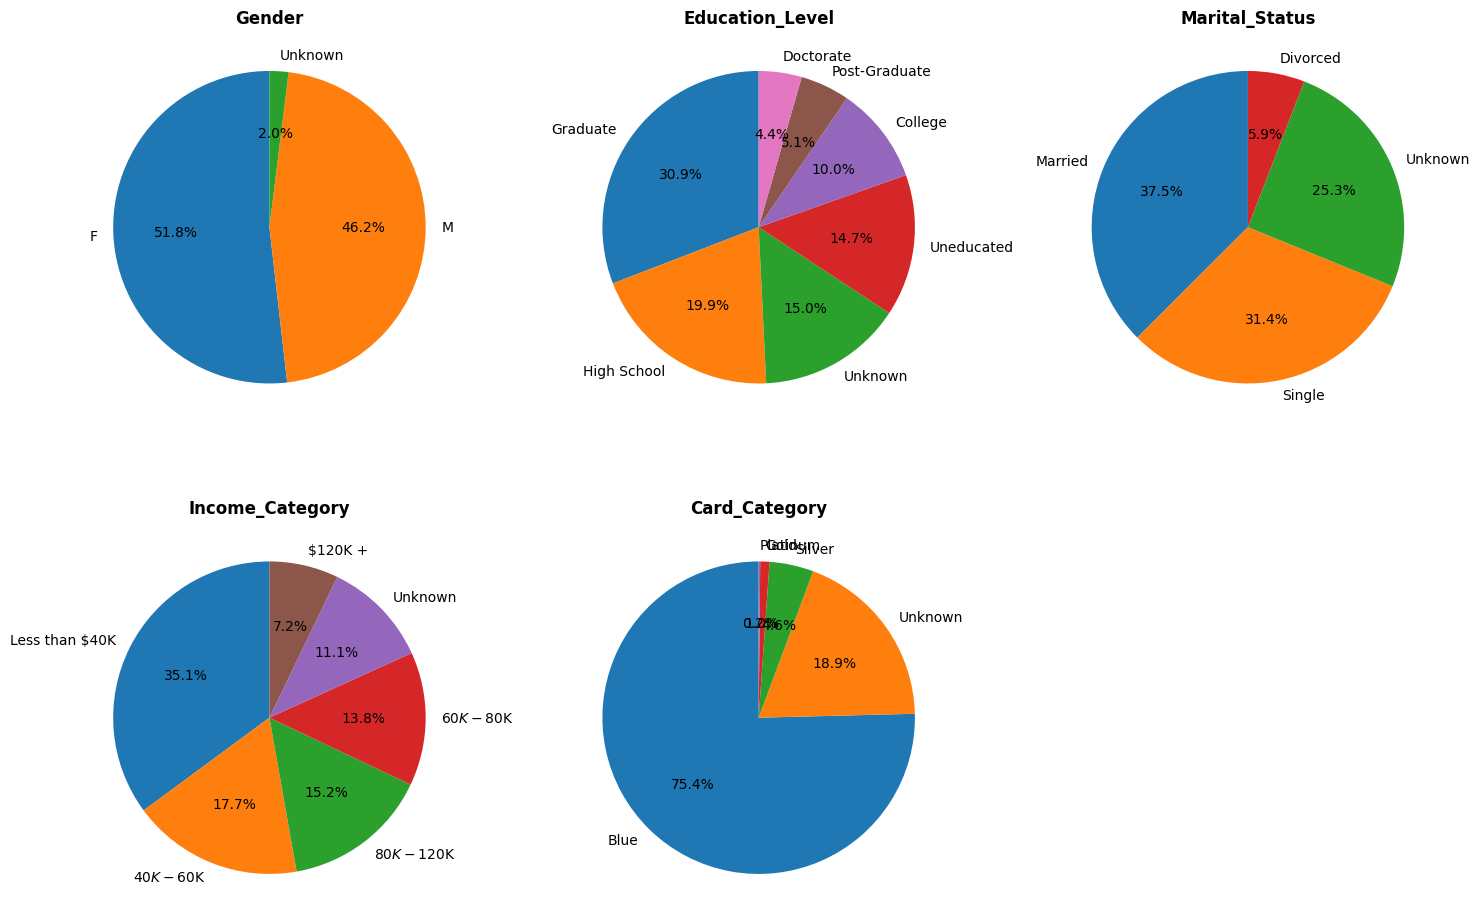

In [ ]:
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for idx, col_name in enumerate(cat_cols):
    value_counts = df[col_name].value_counts()
    axes[idx].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
    axes[idx].set_title(col_name, fontsize=12, fontweight='bold')

for idx in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [14]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 6090 (60.0%)
Validation: 2030 (20.0%)
Test: 2030 (20.0%)


In [15]:
encoder = TargetEncoder(cols=cat_cols, smoothing=10.0, handle_unknown='value')

X_train_enc = encoder.fit_transform(X_train, y_train)
X_val_enc = encoder.transform(X_val)
X_test_enc = encoder.transform(X_test)

joblib.dump(encoder, "../artifacts/target_encoder_nn_base.pkl")

['../artifacts/target_encoder_nn_base.pkl']

In [16]:
scaler = StandardScaler()
# scaler = RobustScaler()
X_train_scaled = X_train_enc.copy()
X_train_scaled = scaler.fit_transform(X_train_enc)

X_val_scaled = X_val_enc.copy()
X_val_scaled = scaler.transform(X_val_enc)

X_test_scaled = X_test_enc.copy()
X_test_scaled = scaler.transform(X_test_enc)

In [17]:
X_train_scaled.shape

(6090, 17)

In [18]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)

X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1, 1)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

In [19]:
BATCH_SIZE = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [20]:
model = nn.Sequential(
    nn.Linear(17, 64),
    # nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 64),
    # nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

from torchinfo import summary
summary(model, input_size=(BATCH_SIZE, 17))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [256, 1]                  --
├─Linear: 1-1                            [256, 64]                 1,152
├─ReLU: 1-2                              [256, 64]                 --
├─Linear: 1-3                            [256, 64]                 4,160
├─ReLU: 1-4                              [256, 64]                 --
├─Linear: 1-5                            [256, 1]                  65
Total params: 5,377
Trainable params: 5,377
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.38
Input size (MB): 0.02
Forward/backward pass size (MB): 0.26
Params size (MB): 0.02
Estimated Total Size (MB): 0.30

In [21]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=1e-3)

In [ ]:
def plot_training_progress(train_losses, val_losses, epoch, num_epochs, best_val_loss):
    """Рисует график прогресса обучения"""
    clear_output(wait=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(train_losses, c='m', linewidth=2, label='Train Loss')
    ax.plot(val_losses, c='y', linewidth=2, label='Val Loss')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Training Progress - Epoch {epoch}/{num_epochs}', fontsize=14, fontweight='bold')
    
    textstr = f'Train Loss (current): {train_losses[-1]:.4f} (best: {min(train_losses):.4f})\n'
    textstr += f'Val Loss (current): {val_losses[-1]:.4f} (best: {best_val_loss:.4f})'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    out = FIGURES_DIR / "nn_training.png"
    plt.savefig(out, bbox_inches='tight')
    display(fig)
    plt.close(fig)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=150, min_delta=1e-4):
        """
        Args:
            patience (int): число эпох без улучшения, после которого обучение останавливается
            min_delta (float): минимальное изменение val_loss, которое считается улучшением
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

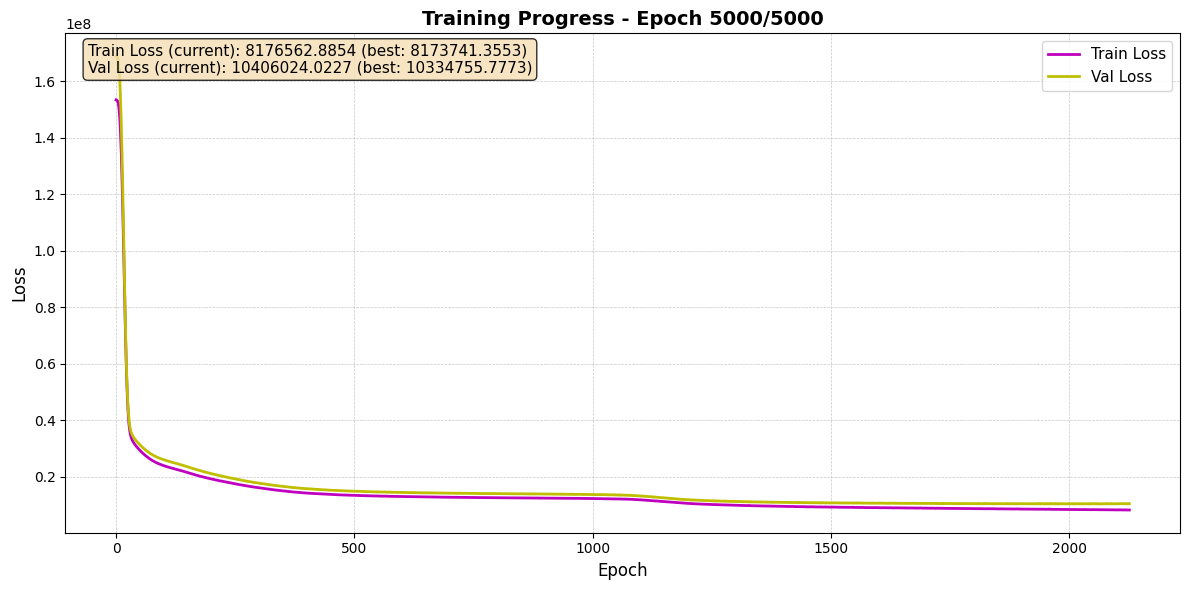

Early stopping triggered at epoch 2126
Лучший лосс на train: 8173741.3553, на val: 10334755.7773
Loaded best model with Val Loss: 10334755.7773


In [ ]:
NUM_EPOCHS = 5000
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

early_stopper = EarlyStopping(patience=150, min_delta=1e-4)
triggered_epoch = None

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_dataloader:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.shape[0]
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_dataloader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            
            pred = model(x_batch)
            loss = criterion(pred, y_batch)

            val_loss += loss.item() * x_batch.shape[0]

    val_loss /= len(val_dataset)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss 
        best_model_state = model.state_dict().copy()

    if early_stopper(val_loss):
        triggered_epoch = epoch
        break

    if epoch % 10 == 0:
        plot_training_progress(train_losses, val_losses, epoch, NUM_EPOCHS, best_val_loss)

plot_training_progress(train_losses, val_losses, NUM_EPOCHS, NUM_EPOCHS, best_val_loss)

if triggered_epoch:
    print(f"Early stopping triggered at epoch {triggered_epoch}")

print(f'Лучший лосс на train: {min(train_losses):.4f}, на val: {best_val_loss:.4f}')

if best_model_state is not None:
    torch.save(best_model_state, '../artifacts/model_nn_best.pth')
    # model.load_state_dict(torch.load('artifacts/model_best.pth'))
    model.load_state_dict(best_model_state)
    print(f"Loaded best model with Val Loss: {best_val_loss:.4f}")


import json, hashlib

config = {
    "target_col": target_col,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "encoder": "TargetEncoder(smoothing=10.0)",
    "scaler": str(scaler)[:-2],
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "epochs": NUM_EPOCHS,
    "device": str(device),
    "random_state": 42,
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "data_alteration": "Only age<=80",
    "architecture": "No BatchNorm",
}

with open("../artifacts/NN_mlflow/nn_config.json", "w") as f:
    json.dump(config, f, indent=2)

data_path = "../data/CreditPrediction.csv"
with open(data_path, "rb") as f:
    data_hash = hashlib.md5(f.read()).hexdigest()
print(f"Data hash: {data_hash}")


In [ ]:
model.eval()
with torch.no_grad():
    X_train_device = X_train_tensor.to(device)
    y_train_device = y_train_tensor.to(device)
    y_train_pred_nn = model(X_train_device).cpu().numpy()
    y_train_actual = y_train_device.cpu().numpy()
    
    X_val_device = X_val_tensor.to(device)
    y_val_device = y_val_tensor.to(device)
    y_val_pred_nn = model(X_val_device).cpu().numpy()
    y_val_actual = y_val_device.cpu().numpy()
    
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)
    y_test_pred_nn = model(X_test_device).cpu().numpy()
    y_test_actual = y_test_device.cpu().numpy()

def calculate_nn_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:  {mse:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  R²:   {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики Neural Network модели')
print('=' * 50)

train_nn_metrics = calculate_nn_metrics(y_train_actual, y_train_pred_nn, 'TRAIN')
val_nn_metrics = calculate_nn_metrics(y_val_actual, y_val_pred_nn, 'VALIDATION')
test_nn_metrics = calculate_nn_metrics(y_test_actual, y_test_pred_nn, 'TEST')

print('\n' + '=' * 50)

Метрики Neural Network модели

TRAIN:
  MSE:  8130799.5000
  RMSE: 2851.4557
  MAE:  1310.9188
  R²:   0.8996

VALIDATION:
  MSE:  10406023.0000
  RMSE: 3225.8368
  MAE:  1519.7943
  R²:   0.8807

TEST:
  MSE:  9660822.0000
  RMSE: 3108.1863
  MAE:  1482.3348
  R²:   0.8828



In [ ]:
with mlflow.start_run(run_name="NN_baseline"):
    
    mlflow.log_params(config)
    mlflow.log_param("data_hash", data_hash)
    
    mlflow.log_metrics({
        "train_mse": train_nn_metrics["MSE"],
        "train_rmse": train_nn_metrics["RMSE"],
        "train_mae": train_nn_metrics["MAE"],
        "train_r2": train_nn_metrics["R2"],
        "val_mse": val_nn_metrics["MSE"],
        "val_rmse": val_nn_metrics["RMSE"],
        "val_mae": val_nn_metrics["MAE"],
        "val_r2": val_nn_metrics["R2"],
        "test_mse": test_nn_metrics["MSE"],
        "test_rmse": test_nn_metrics["RMSE"],
        "test_mae": test_nn_metrics["MAE"],
        "test_r2": test_nn_metrics["R2"],
    })
    
    mlflow.pytorch.log_model(model, "model")
    
    mlflow.log_artifact("../artifacts/NN_mlflow/nn_config.json")
    mlflow.log_artifact(data_path, "data")

2026/05/09 15:51:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 15:51:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/09 15:51:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.1+cu118) contains a local version label (+cu118). MLflow logged a pip requirement for this package as 'torch==2.7.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/09 15:51:24 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.1+cu118) contains a local version label (+

с batchnorm обучение шло менее стабильно, однако на тренировочной части метрики показали себя лучше, чем без batch norm. При одинаковых параметрах модель с batchnorm сильнее переобучилась. 